In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

In [2]:
# 데이터 불러오기
df = pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)  # 'Id' 열 제거

In [4]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# 결측치 확인
missing_values = df.isnull().sum()
if missing_values.any():
    print("결측치가 존재합니다:")
    print(missing_values[missing_values > 0])

결측치가 존재합니다:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [6]:
# 결측치 처리
## 전체 데이터의 30% 이상 결측치인 열 제거
missing_ratio = df.isnull().mean()
missing_cols_30per = missing_ratio[missing_ratio >= 0.3].index

print(f"30% 이상 결측치인 열: {list(missing_cols_30per)}")
df = df.drop(missing_cols_30per, axis=1)
df.head() 

30% 이상 결측치인 열: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [17]:
# LotFrontage는 평균값으로 대체
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())

# 나머지 결측치 처리
## 숫자형 데이터는 중앙값으로 대체
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

## 범주형 데이터는 최빈값으로 대체
cat_cols = df.columns[df.dtypes == 'object']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## 결측치 처리 후 남은 결측치 개수 확인
print("결측치 처리 후 남은 결측치 개수:")
print(df.isnull().sum().sum())

결측치 처리 후 남은 결측치 개수:
0


In [18]:
# 입력 데이터와 정답 데이터 분리
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [19]:
# 범주형 데이터 인코딩
X = pd.get_dummies(X, drop_first=True)
X.shape

(1460, 229)

In [20]:
# 학습 데이터 및 테스트 데이터 분리
## 8:2 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"학습 데이터 개수: {X_train.shape[0]}, 테스트 데이터 개수: {X_test.shape[0]}")

학습 데이터 개수: 1168, 테스트 데이터 개수: 292


In [21]:
# Decision Tree 모델 학습
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train);

In [22]:
# 예측
y_pred = model.predict(X_test)

In [23]:
# 모델 평가 
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}") 
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 1731772294.61
Mean Absolute Error (MAE): 27014.04
Root Mean Squared Error (RMSE): 41614.57
R-squared (R2): 0.77


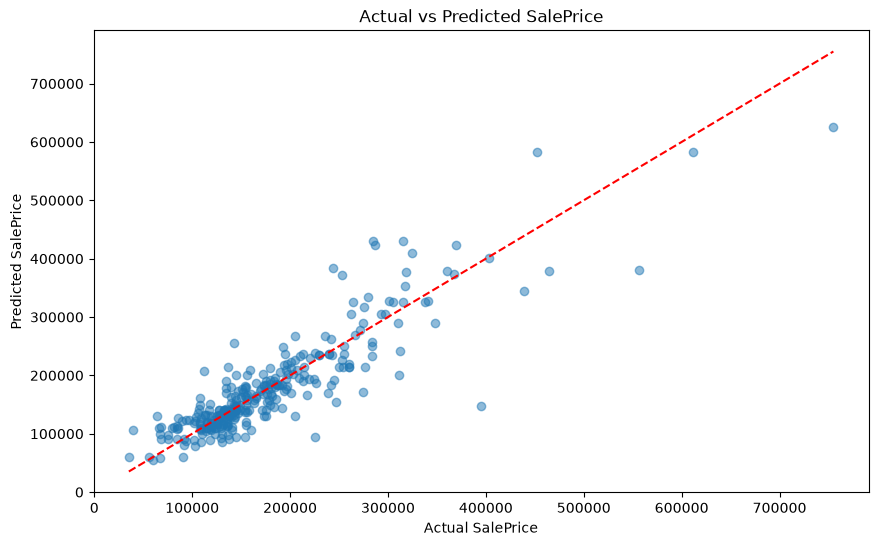

In [24]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.show()

In [ ]:
# 평가 결과 해석
print("모델 평가 결과 해석:")a
print(f"Mean Squared Error (MSE): {mse:.2f} - 예측값과 실제값의 차이를 제곱하여 평균한 값으로, 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.")
print(f"Mean Absolute Error (MAE): {mae:.2f} - 예측값과 실제값의 차이의 절대값을 평균한 값으로, 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} - MSE의 제곱근으로, 단위가 실제값과 동일하여 해석이 용이합니다. 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.")
print(f"R-squared (R2): {r2:.2f} - 모델이 실제 데이터를 얼마나 잘 설명하는지를 나타내는 지표로, 1에 가까울수록 모델의 설명력이 높음을 의미합니다.")


모델 평가 결과 해석:
Mean Squared Error (MSE): 1731772294.61 - 예측값과 실제값의 차이를 제곱하여 평균한 값으로, 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.
Mean Absolute Error (MAE): 27014.04 - 예측값과 실제값의 차이의 절대값을 평균한 값으로, 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.
Root Mean Squared Error (RMSE): 41614.57 - MSE의 제곱근으로, 단위가 실제값과 동일하여 해석이 용이합니다. 값이 작을수록 모델의 예측이 실제값에 가까움을 의미합니다.
R-squared (R2): 0.77 - 모델이 실제 데이터를 얼마나 잘 설명하는지를 나타내는 지표로, 1에 가까울수록 모델의 설명력이 높음을 의미합니다.
